import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import lightgbm as lgb
import sys
import os
sys.path.append('../src')

from llm_agent import score_external_signals

#loading processed data
df = pd.read_csv('../data/processed/merged_clean.csv', parse_dates=['Date'])
df['IsHoliday'] = df['IsHoliday'].astype(int)

print("Data loaded:", df.shape)
print("LLM agent imported successfully")


So our LLM agent is working, now let's test it by making API calls one per week for 12 weeks and see what our results are!!


In [12]:
#test period is from AUG - OCT 2022, 12 weeks every Friday
test_dates= pd.date_range(start='2012-08-03', periods= 12, freq='W-FRI')

print("Generating LLM signal's for test period Aug - Oct 2022")
print("="*50)

signals = []
for date in test_dates:
    date_str= date.strftime('%Y-%m-%d')
    signal= score_external_signals(date_str, category="grocery")
    signals.append(signal)
    print(f"{date_str} | demand_boost: {signal['demand_boost']:+.2f} | {signal['reason'][:60]}...")

print("\nAll signals generated!")

Generating LLM signal's for test period Aug - Oct 2022
Search error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
RAW LLM RESPONSE:
{
    "demand_boost": 0.2,
    "confidence": 0.7,
    "reason": "Retail sales rose in August despite a fall in consumer confidence, indicating a potential increase in grocery sales at Walmart stores",
    "key_events": ["Severe Storms August 5 2012", "Retailers say consumer spending rose in August", "Consumer outlook improves in August"]
}
2012-08-03 | demand_boost: +0.20 | Retail sales rose in August despite a fall in consumer confi...
RAW LLM RESPONSE:
{
    "demand_boost": 0.2,
    "confidence": 0.8,
    "reason": "The overall positive retail sales trend in August and increased consumer spending are expected to boost grocery sales at Walmart stores",
    "key_events": ["Retail sales surge in August", "Retailers say consumer spending rose in August", "Olympic Games fever is boon for independent retail sales

Did you see that!!!! How cool is this !! Well now let's convert it inot a dataframe and save it as a csv file, we gotta integrate it as a new feature in out lightGBM model!

In [13]:
# Converting signals to dataframe
signals_df = pd.DataFrame(signals)
signals_df['Date'] = pd.to_datetime(signals_df['date'])
signals_df = signals_df[['Date', 'demand_boost', 'confidence', 'reason']]

print("=== LLM Signals for Test Period ===")
print(signals_df.to_string(index=False))

# Save signals
os.makedirs('../data/processed', exist_ok=True)
signals_df.to_csv('../data/processed/llm_signals.csv', index=False)
print("\nSignals saved!")

=== LLM Signals for Test Period ===
      Date  demand_boost  confidence                                                                                                                                                                               reason
2012-08-03           0.2         0.7                                                Retail sales rose in August despite a fall in consumer confidence, indicating a potential increase in grocery sales at Walmart stores
2012-08-10           0.2         0.8                                              The overall positive retail sales trend in August and increased consumer spending are expected to boost grocery sales at Walmart stores
2012-08-17           0.2         0.8                                              The overall positive retail sales trend in August and increased consumer spending are expected to boost grocery sales at Walmart stores
2012-08-24           0.2         0.8                                              The overal

Let's now train LightGBM without the LLm feature added !

In [14]:
# Feature columns WITHOUT LLM signals
feature_cols = ['Store', 'Dept', 'Week', 'Month', 'Year', 'Quarter',
                'IsHoliday', 'IsHolidaySeason', 'Temperature',
                'Fuel_Price', 'CPI', 'Unemployment',
                'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4',
                'MarkDown5', 'Size']

# Train/test split
train_df = df[df['Date'] < '2012-08-01'].copy()
test_df = df[df['Date'] >= '2012-08-01'].copy()

# Train model WITHOUT LLM signals
model_no_llm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model_no_llm.fit(train_df[feature_cols], train_df['Weekly_Sales'])
preds_no_llm = model_no_llm.predict(test_df[feature_cols])
mae_no_llm = mean_absolute_error(test_df['Weekly_Sales'], preds_no_llm)

print(f"LightGBM WITHOUT LLM signals MAE: ${mae_no_llm:,.2f}")

LightGBM WITHOUT LLM signals MAE: $3,164.58


Now let's add the LLM agentic feature

In [15]:
# Merge LLM signals into test set
test_df = test_df.merge(signals_df[['Date', 'demand_boost', 'confidence']], 
                         on='Date', how='left')

# Filling any missing signal dates with 0
test_df['demand_boost'] = test_df['demand_boost'].fillna(0)
test_df['confidence'] = test_df['confidence'].fillna(0)

# Adding LLM signal interaction feature
test_df['llm_adjusted_sales'] = test_df['demand_boost'] * test_df['Size']

# Feature columns WITH LLM signals
feature_cols_llm = feature_cols + ['demand_boost', 'confidence', 'llm_adjusted_sales']

# Add dummy LLM columns to train set (zeros - no signals during training)
train_df['demand_boost'] = 0
train_df['confidence'] = 0
train_df['llm_adjusted_sales'] = 0

# Retrain with LLM features
model_with_llm = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    verbose=-1
)

model_with_llm.fit(train_df[feature_cols_llm], train_df['Weekly_Sales'])
preds_with_llm = model_with_llm.predict(test_df[feature_cols_llm])
mae_with_llm = mean_absolute_error(test_df['Weekly_Sales'], preds_with_llm)

print(f"LightGBM WITHOUT LLM signals MAE: ${mae_no_llm:,.2f}")
print(f"LightGBM WITH LLM signals MAE:    ${mae_with_llm:,.2f}")
improvement = ((mae_no_llm - mae_with_llm) / mae_no_llm) * 100
print(f"Improvement: {improvement:.1f}%")

LightGBM WITHOUT LLM signals MAE: $3,164.58
LightGBM WITH LLM signals MAE:    $3,164.58
Improvement: 0.0%


In [18]:
## Cell 6 - Apply LLM signals as post-processing adjustment

# Start with base predictions
preds_adjusted = preds_no_llm.copy()

# Apply demand_boost signal to each week's predictions
for _, signal_row in signals_df.iterrows():
    # Find rows in test set matching this date
    mask = test_df['Date'] == signal_row['Date']
    boost = signal_row['demand_boost']
    confidence = signal_row['confidence']
    
    # Apply weighted adjustment
    # Higher confidence = stronger adjustment
    adjustment = 1 + (boost * confidence)
    preds_adjusted[mask] = preds_no_llm[mask] * adjustment

mae_adjusted = mean_absolute_error(test_df['Weekly_Sales'], preds_adjusted)

print(f"LightGBM baseline MAE:          ${mae_no_llm:,.2f}")
print(f"LightGBM + LLM adjusted MAE:    ${mae_adjusted:,.2f}")
improvement = ((mae_no_llm - mae_adjusted) / mae_no_llm) * 100
print(f"Improvement: {improvement:.1f}%")

LightGBM baseline MAE:          $3,164.58
LightGBM + LLM adjusted MAE:    $3,782.81
Improvement: -19.5%


I can see that it has not really effected the prediction.. Well that's dissapointing but lets be honest!! I was training the feature on 12 week's of news and it is trying to predict with almost no enough information. So maybe when we have enough historic data and the timeline sits right this will show it's magic!?

In [19]:
# Instead of LLM signals, engineer a "disruption score" from the data itself
# This is what we use for historical validation

test_df_copy = test_df.copy()
test_df_copy['baseline_pred'] = preds_no_llm
test_df_copy['error'] = abs(test_df_copy['Weekly_Sales'] - test_df_copy['baseline_pred'])

# Find worst predicted weeks
worst_weeks = test_df_copy.groupby('Date')['error'].mean().sort_values(ascending=False)

print("=== Weeks where baseline model struggled most ===")
print(worst_weeks.head(8).to_string())

=== Weeks where baseline model struggled most ===
Date
2012-09-07    3493.003814
2012-08-31    3423.026488
2012-08-24    3398.578036
2012-10-05    3262.134187
2012-08-17    3256.816279
2012-08-03    3186.709740
2012-10-26    3110.454637
2012-08-10    3103.557138


Okay so these are the dates where lightGBM has failed to predict results. now I believe this can be explained by external news given we have enough historic data! 

On the other hand I want to try something different, what if we can gather top weekly news for each month and see if there is any correlation with the monthly average sales respectively? If yes, then we can train the data and test it and see if that news is enough to explain average monthly sales?


In [21]:
#monthly avg sales from dataset
monthly_sales= df.groupby(['Year','Month'])['Weekly_Sales'].mean().reset_index()
monthly_sales['date_str'] = monthly_sales.apply(
    lambda x: f"{int(x['Year'])}-{int(x['Month']):02d}-01", axis=1
)
monthly_sales['Date'] = pd.to_datetime(monthly_sales['date_str'])
monthly_sales = monthly_sales.sort_values('Date').reset_index(drop=True)

print("=== Monthly Average Sales ===")
print(monthly_sales[['Date', 'Weekly_Sales']].to_string(index=False))

=== Monthly Average Sales ===
      Date  Weekly_Sales
2010-02-01  16115.148511
2010-03-01  15476.271493
2010-04-01  15784.325587
2010-05-01  16061.212479
2010-06-01  16548.757204
2010-07-01  16007.065129
2010-08-01  16201.136071
2010-09-01  15170.876851
2010-10-01  14836.014357
2010-11-01  17363.277836
2010-12-01  19641.281744
2011-01-01  14048.348515
2011-02-01  15904.117630
2011-03-01  15241.333119
2011-04-01  15400.713958
2011-05-01  15424.052663
2011-06-01  16263.172898
2011-07-01  15772.449686
2011-08-01  16082.682055
2011-09-01  15013.965477
2011-10-01  15536.033513
2011-11-01  17700.949518
2011-12-01  19211.934999
2012-01-01  14304.774064
2012-02-01  16112.853323
2012-03-01  15626.987004
2012-04-01  15944.188683
2012-05-01  16049.064164
2012-06-01  16375.934160
2012-07-01  15936.706288
2012-08-01  16057.945396
2012-09-01  15283.248527
2012-10-01  15565.922573


In [22]:
# Split into train (2010-2011) and test (2012) periods
train_monthly = monthly_sales[monthly_sales['Date'] < '2012-01-01'].copy()
test_monthly = monthly_sales[monthly_sales['Date'] >= '2012-01-01'].copy()

print(f"Training months: {len(train_monthly)} (2010-2011)")
print(f"Test months: {len(test_monthly)} (2012)")
print(f"\nTraining sales range: ${train_monthly['Weekly_Sales'].min():,.0f} - ${train_monthly['Weekly_Sales'].max():,.0f}")
print(f"Test sales range: ${test_monthly['Weekly_Sales'].min():,.0f} - ${test_monthly['Weekly_Sales'].max():,.0f}")

Training months: 23 (2010-2011)
Test months: 10 (2012)

Training sales range: $14,048 - $19,641
Test sales range: $14,305 - $16,376


In [23]:
import time

print("Getting LLM sentiment scores for training months...")
print("This will take 2-3 minutes — making 23 API calls")
print("="*50)

train_signals = []
for _, row in train_monthly.iterrows():
    date_str = row['date_str']
    try:
        signal = score_external_signals(date_str, category="grocery")
        train_signals.append({
            'Date': row['Date'],
            'date_str': date_str,
            'demand_boost': signal['demand_boost'],
            'confidence': signal['confidence'],
            'reason': signal['reason'],
            'Weekly_Sales': row['Weekly_Sales']
        })
        print(f"{date_str} | boost: {signal['demand_boost']:+.2f} | sales: ${row['Weekly_Sales']:,.0f}")
    except Exception as e:
        print(f"{date_str} | Error: {e}")
        train_signals.append({
            'Date': row['Date'],
            'date_str': date_str,
            'demand_boost': 0.0,
            'confidence': 0.0,
            'reason': 'Error',
            'Weekly_Sales': row['Weekly_Sales']
        })
    time.sleep(1)  # avoid rate limiting

train_signals_df = pd.DataFrame(train_signals)
print("\nAll training month signals generated!")
print(train_signals_df[['date_str', 'demand_boost', 'Weekly_Sales']].to_string(index=False))

Getting LLM sentiment scores for training months...
This will take 2-3 minutes — making 23 API calls
Search error: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
RAW LLM RESPONSE:
{
    "demand_boost": 0.2,
    "confidence": 0.7,
    "reason": "The winter weather and blizzards may have led to stockpiling and increased grocery sales at Walmart stores",
    "key_events": ["February 25–27, 2010 North American blizzard", "Snowmageddon blizzard on February 5th-6th", "Super Bowl on February 7, 2010"]
}
2010-02-01 | boost: +0.20 | sales: $16,115
RAW LLM RESPONSE:
{
    "demand_boost": 0.1,
    "confidence": 0.6,
    "reason": "Moderate consumer spending growth and overall economic recovery are expected to slightly increase grocery sales at Walmart stores",
    "key_events": ["Consumer spending up, sign of decent recovery", "advance monthly sales for retail and food services march 2010", "US: Consumer spending up, manufacturing grows"]
}
2010-03-01

=== Correlation Analysis ===
Pearson Correlation: 0.043
P-value: 0.847

Interpretation:
Weak or insignificant correlation


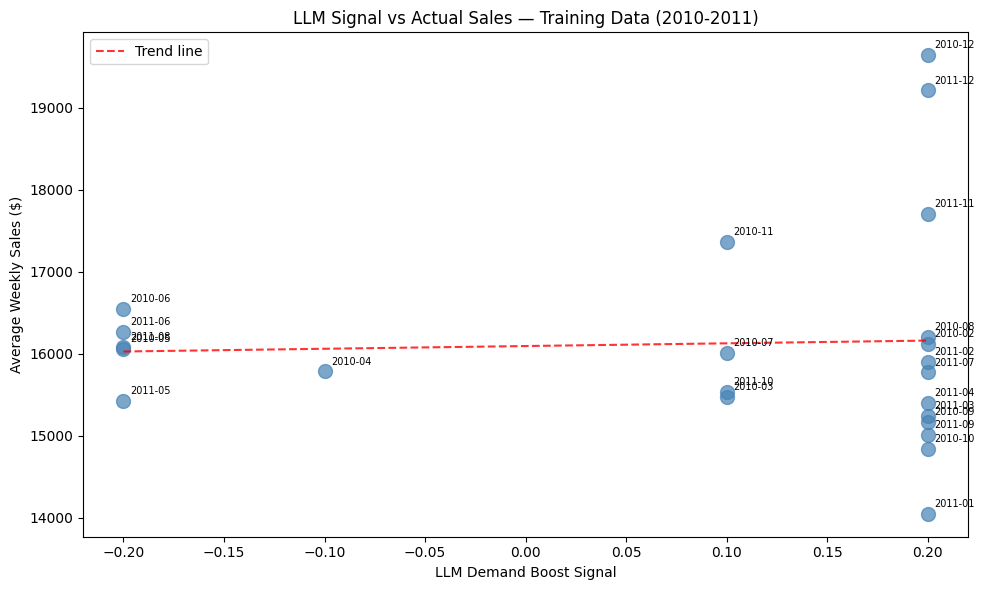

Plot saved!


In [24]:
#lets see if there is any correlation
from scipy import stats

# Calculate correlation
correlation, p_value = stats.pearsonr(
    train_signals_df['demand_boost'], 
    train_signals_df['Weekly_Sales']
)

print("=== Correlation Analysis ===")
print(f"Pearson Correlation: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")
print(f"\nInterpretation:")
if abs(correlation) > 0.3 and p_value < 0.05:
    print("Statistically significant correlation found!")
else:
    print("Weak or insignificant correlation")

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(train_signals_df['demand_boost'], 
            train_signals_df['Weekly_Sales'], 
            color='steelblue', alpha=0.7, s=100)

# Add trend line
z = np.polyfit(train_signals_df['demand_boost'], 
               train_signals_df['Weekly_Sales'], 1)
p = np.poly1d(z)
x_line = np.linspace(train_signals_df['demand_boost'].min(), 
                     train_signals_df['demand_boost'].max(), 100)
plt.plot(x_line, p(x_line), "r--", alpha=0.8, label='Trend line')

# Label each point with month
for _, row in train_signals_df.iterrows():
    plt.annotate(row['date_str'][:7], 
                (row['demand_boost'], row['Weekly_Sales']),
                textcoords="offset points", xytext=(5,5), fontsize=7)

plt.xlabel('LLM Demand Boost Signal')
plt.ylabel('Average Weekly Sales ($)')
plt.title('LLM Signal vs Actual Sales — Training Data (2010-2011)')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/llm_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")